In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

REPO_ROOT = next(
    path for path in (Path.cwd(), *Path.cwd().parents)
    if (path / "rayder").is_dir()
)
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from rayder.open_illumination import (
    OLAT_CAMERA_IDS,
    OLAT_OBJECTS,
    OLATLightPattern,
    OpenIlluminationOLAT,
)

In [2]:
OLAT_OBJECTS, OLAT_CAMERA_IDS

({1: 'obj_01_egg',
  2: 'obj_02_sculpture',
  3: 'obj_03_pumpkin',
  4: 'obj_04_dolphin',
  5: 'obj_05_hedgehog',
  6: 'obj_06_chicken',
  7: 'obj_07_pumpkin2',
  8: 'obj_08_sculpture2',
  9: 'obj_09_ball',
  10: 'obj_10_pumpkin3',
  11: 'obj_11_pine',
  12: 'obj_12_pine2',
  13: 'obj_13_mushroom',
  14: 'obj_14_basketball',
  15: 'obj_15_pumpkin4',
  16: 'obj_16_friends_cup',
  17: 'obj_17_pumpkin5',
  18: 'obj_18_fabric_hat',
  19: 'obj_19_cylinder',
  20: 'obj_20_greenhead'},
 ('A1',
  'A2',
  'A3',
  'A4',
  'A5',
  'A6',
  'B2',
  'B3',
  'B4',
  'B5',
  'B6',
  'C1',
  'C2',
  'C3',
  'C4',
  'C5',
  'C6',
  'D1',
  'D3',
  'D4',
  'D5',
  'D6'))

In [3]:
dataset = OpenIlluminationOLAT(
    root=REPO_ROOT / "notebooks/data/openillumination-mini",
    object_id=20,  # use 6 for the chicken; use 5 for the hedgehog; use 4 for the dolphin; 3 - pumpkin; 2 - statue; 1 - egg; 8 - sculpture2; 12 - pine2; 20 - greenhead;
    download_missing=True,
)

In [4]:

# Exact-file downloads only: JPEGs, masks, and camera metadata, never RAW/*.raw.
downloaded = dataset.download(
    cameras=[("A", 1), ("A", 2), ("A", 3), ("A", 4), ("A", 5), ("A", 6), ("B", 2), ("B", 3), ("B", 4), ("B", 5), ("B", 6), ("C", 1), ("C", 2), ("C", 3), ("C", 4), ("C", 5), ("C", 6)],
    light_indices=range(142),
)
camera_info = dataset.camera_metadata(("A", 1))
len(downloaded), camera_info["split"], np.asarray(camera_info["transform_matrix"]).shape

/mnt/warm/dev/rayder/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


(2435, 'train', (4, 4))

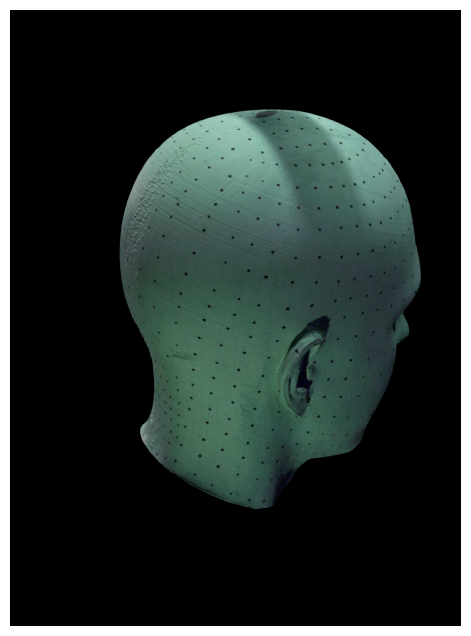

In [5]:
pattern = OLATLightPattern.from_mapping({
    0: 1.0,
    8: 0.5,
    16: 1.0,
    32: 0.75,
    64: 1.0,
    112: 0.5,
})
configuration = dataset.configuration(("A", 1), pattern)

preview = dataset.render(
    configuration,
    exposure_ev=0.0,
    auto_exposure=True,
    mask="object",  # None, "object", or "combined"
    subtract_background=True,
    tone_map="reinhard",
)

plt.figure(figsize=(8, 8))
plt.imshow(preview)
plt.axis("off")
plt.show()

In [6]:
rng = np.random.default_rng(0)

# Same view, different illumination.
same_view = dataset.sample_pair(
    same="view", camera=("A", 1), lights_per_pattern=8, rng=rng
)

# Same illumination, different views.
same_light = dataset.sample_pair(
    same="light",
    camera=("A", 1),
    other_camera=("C", 4),
    light_pattern=pattern,
    rng=rng,
)

# Perturb illumination while preserving its intensities.
shuffled = pattern.shuffled(rng)
masked = pattern.dropout(probability=0.25, rng=rng)
{
    "same_view": [(item.camera, item.lights.active_indices) for item in same_view],
    "same_light": [(item.camera, item.lights.active_indices) for item in same_light],
    "shuffled": shuffled.active_indices,
    "masked": masked.active_indices,
}

{'same_view': [('A1', (2, 5, 10, 37, 42, 70, 86, 114)),
  ('A1', (38, 74, 77, 85, 95, 98, 115, 129))],
 'same_light': [('A1', (0, 8, 16, 32, 64, 112)),
  ('C4', (0, 8, 16, 32, 64, 112))],
 'shuffled': (26, 58, 68, 73, 118, 136),
 'masked': (0, 8, 16, 64, 112)}

In [7]:
import math 
import torch
import torchvision.transforms.v2 as TF

def plot_grid(images, size = (512, 512)):
    X, Y, _, _, _ = images.shape


    fig, axes = plt.subplots(X, Y, figsize=(18, 18))
    res = TF.Compose([TF.ToImage(), TF.Resize(size)])

    for y in range(Y):
        for x in range(X):
            i = y * x + x
            axes[x, y].imshow(images[x, y, :, :, :])
            axes[x, y].axis("off")
    fig.tight_layout()
    plt.show()


In [12]:

pattern = OLATLightPattern.from_mapping({
    0: 1.0,
    8: 0.5,
    16: 1.0,
    32: 0.75,
    64: 0.8,
    112: 0.25,
})

cameras=[("A", 1), ("A", 2), ("A", 3), ("A", 4), ("A", 5), ("A", 6), ("B", 2), ("B", 3), ("B", 4), ("B", 5), ("B", 6)] #, ("C", 1), ("C", 2), ("C", 3), ("C", 4), ("C", 5), ("C", 6)]
wx = torch.randn(len(cameras))
wy = wx.T
Ws = (wy[None,...] * wx[...,None])
Ws = Ws[:, :6].softmax(dim=-1)

In [13]:

images = list(dataset.iter_render_weight_batches(
    weights=Ws,
    cameras=cameras,
    light_indices=[0, 8, 16, 32, 64, 128],
    size=(512, 512)
))

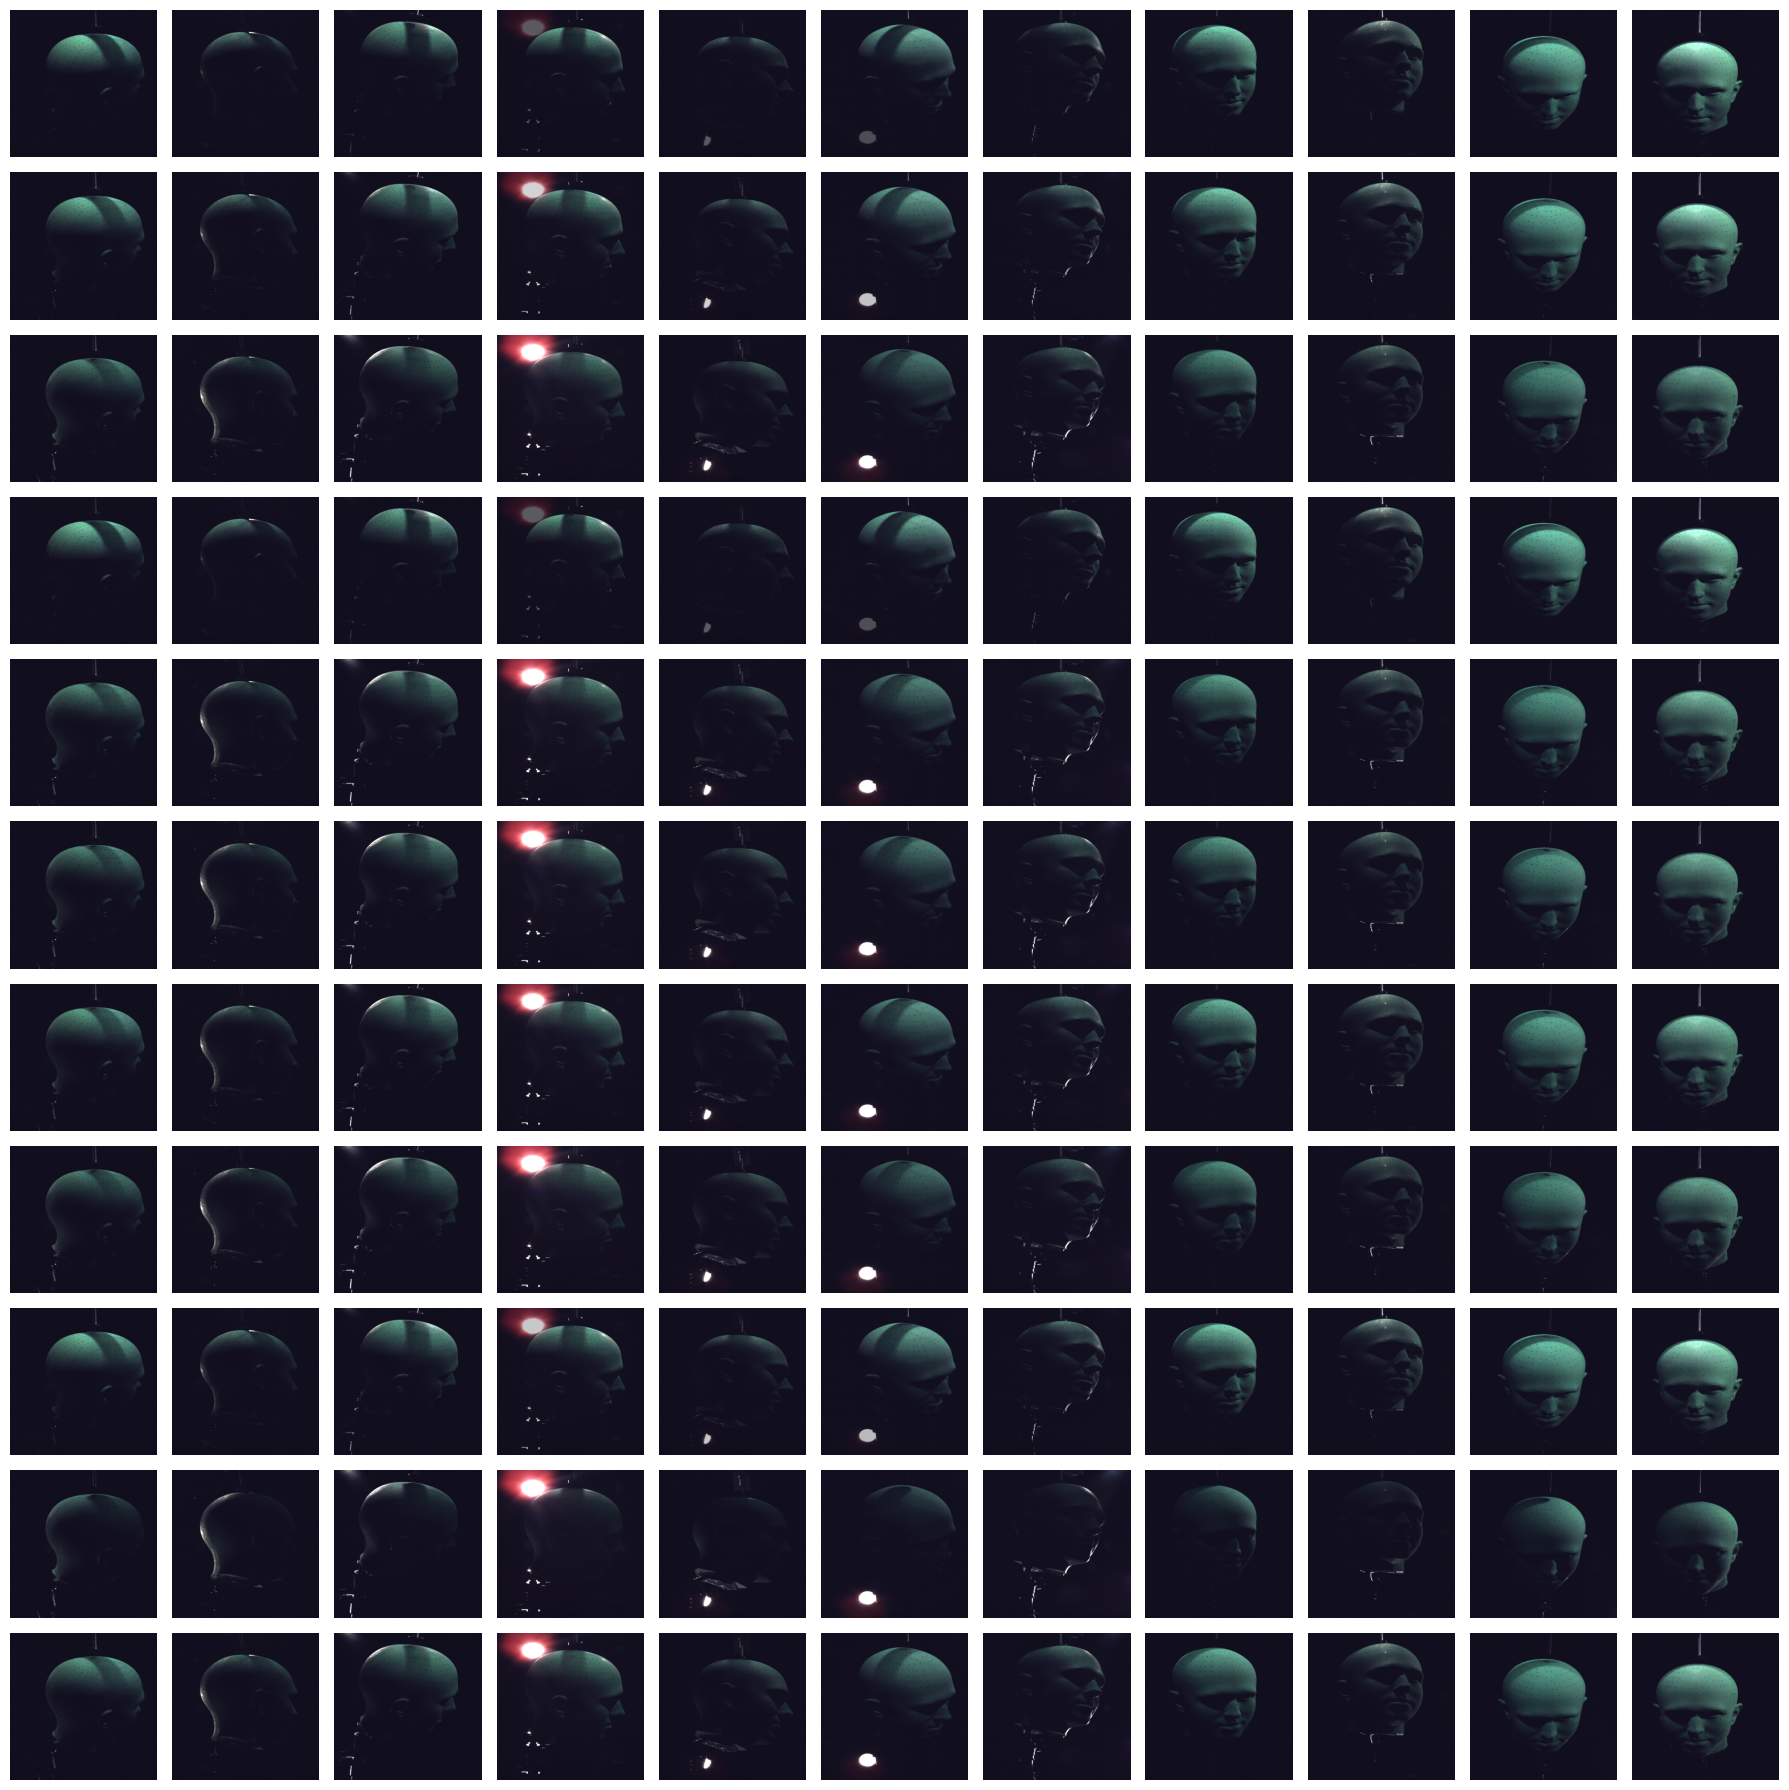

In [17]:
plot_grid(torch.clamp(torch.tensor(images[0]) * 3.0, 0, 1))